# Appliance Energy Prediction

## Loading library and dataset

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import *

from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.compose import make_column_selector, ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_og = pd.read_csv("D:\\Data Sets\\energydata_complete.csv")
df_og.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Basic Information on dataset

In [3]:
df_og.shape

(19735, 29)

In [4]:
df_og.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

This is what each column name means

- date time year-month-day hour:minute:second 
- Appliances, energy use in Wh
- lights, energy use of light fixtures in the house in Wh
- T1, Temperature in kitchen area, in Celsius
- RH_1, Humidity in kitchen area, in %
- T2, Temperature in living room area, in Celsius
- RH_2, Humidity in living room area, in %
- T3, Temperature in laundry room area
- RH_3, Humidity in laundry room area, in %
- T4, Temperature in office room, in Celsius
- RH_4, Humidity in office room, in %
- T5, Temperature in bathroom, in Celsius
- RH_5, Humidity in bathroom, in %
- T6, Temperature outside the building (north side), in Celsius
- RH_6, Humidity outside the building (north side), in %
- T7, Temperature in ironing room , in Celsius
- RH_7, Humidity in ironing room, in %
- T8, Temperature in teenager room 2, in Celsius
- RH_8, Humidity in teenager room 2, in %
- T9, Temperature in parents room, in Celsius
- RH_9, Humidity in parents room, in %
- To, Temperature outside (from Chievres weather station), in Celsius
- Pressure (from Chievres weather station), in mm Hg
- RH_out, Humidity outside (from Chievres weather station), in %
- Wind speed (from Chievres weather station), in m/s
- Visibility (from Chievres weather station), in km
- Tdewpoint (from Chievres weather station), Â°C
- rv1, Random variable 1, nondimensional
- rv2, Random variable 2, nondimensional

## Null Values checking

In [5]:
df_og.isna().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

There are no null values

## Statistical inference of dataset

In [6]:
df_og.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


### Conclusion

- average energy usage is 97 units with 50% of people using 50 to 100 units of energy, and a max of 1080 units show that there might be some industrial buildings here as well and mean and std being similar also indicate that it is mostly normally distributed dataset.

## Visualisation

In [7]:
def plot_df(df: pd.DataFrame):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = df.select_dtypes(include=["object"]).columns

    # ---------- CATEGORICAL ----------
    if len(cat_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(cat_cols) / n_cols)

        plt.figure(figsize=(n_cols * 5, n_rows * 5))

        for i, col in enumerate(cat_cols, 1):
            plt.subplot(n_rows, n_cols, i)

            values = df[col].value_counts()
            top = values.head(5)

            if len(values) > 5:
                top["Others"] = values[5:].sum()

            plt.pie(top, labels=top.index, autopct="%1.1f%%", startangle=90)
            plt.title(f"Pie Chart - {col}")

        plt.suptitle("Categorical Columns - Pie Chart", y=1.02)
        plt.tight_layout()
        plt.show()

    # ---------- NUMERICAL BOXPLOTS ----------
    if len(num_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(num_cols) / n_cols)

        plt.figure(figsize=(n_cols * 5, n_rows * 5))

        for i, col in enumerate(num_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            sns.boxplot(x=df[col])
            plt.title(f"Boxplot - {col}")

        plt.suptitle("Numerical Columns - Boxplot", y=1.02)
        plt.tight_layout()
        plt.show()

        # ---------- HISTOGRAMS ----------
        plt.figure(figsize=(n_cols * 5, n_rows * 5))

        for i, col in enumerate(num_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            sns.histplot(df[col].dropna(), kde=True, bins=30)
            plt.axvline(df[col].mean(), linestyle="dashed", linewidth=1)
            plt.title(f"Histplot - {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")

        plt.suptitle("Numerical Columns - Histplot", y=1.02)
        plt.tight_layout()
        plt.show()

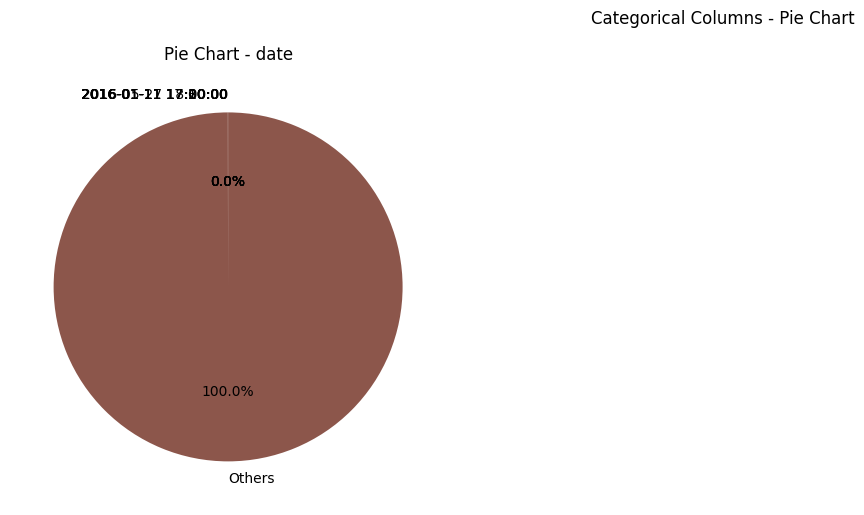

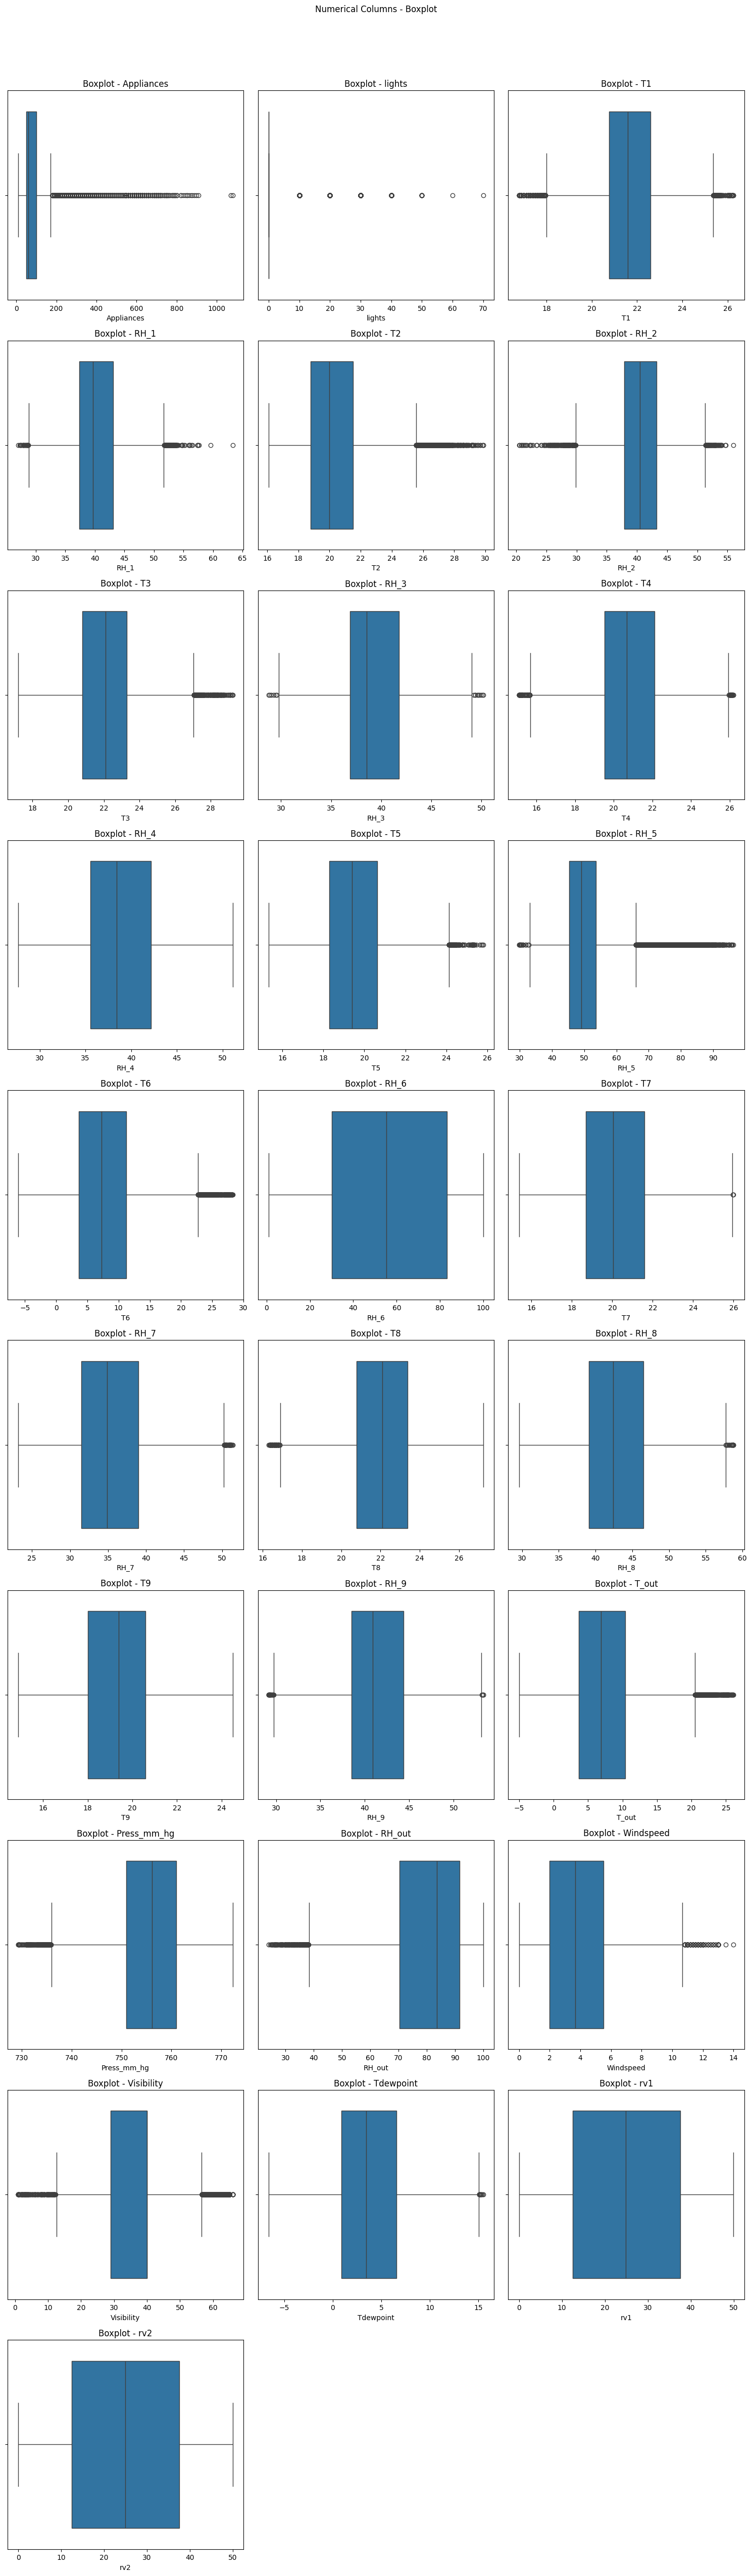

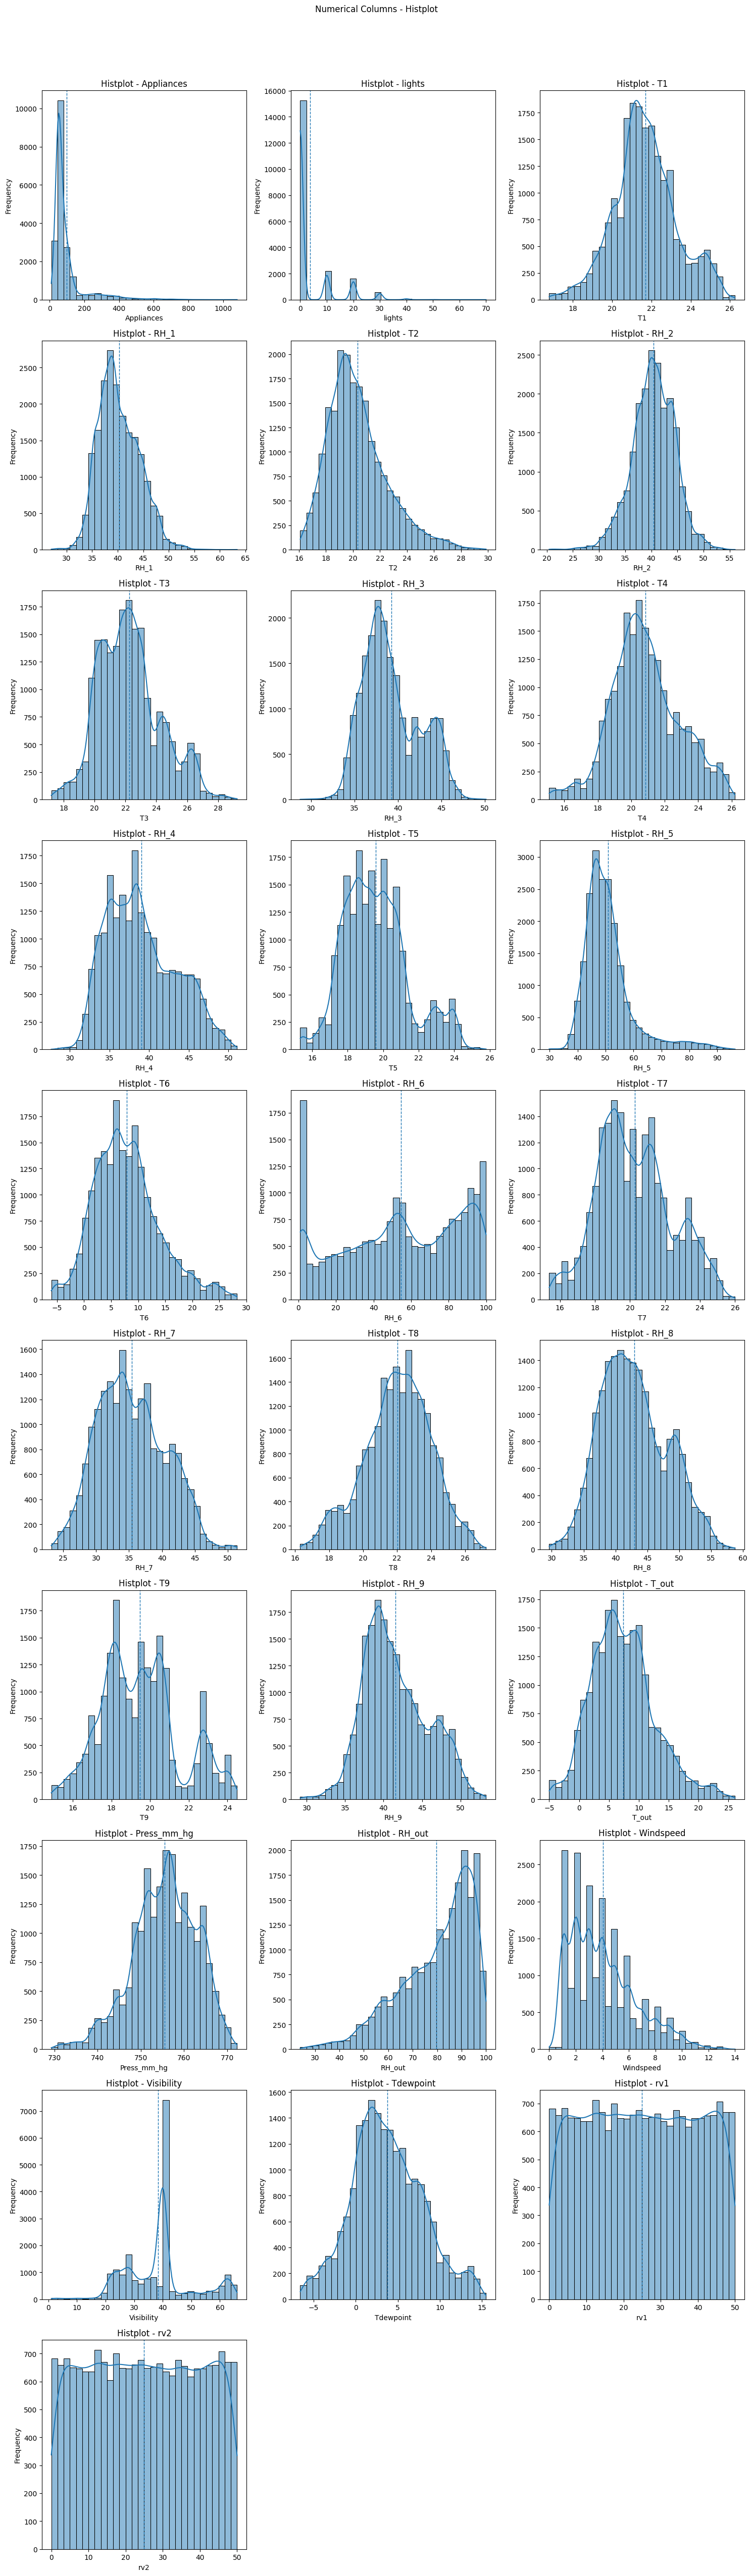

In [8]:
plot_df(df_og)

### Conclusion

- Our date column is useless so we will drop it
- Data has a lot of outliers so we will have to handle that as well
- Quite a lot of our data is very uniformly distributed but we still have to scale it.
- None of the single column is strongly correlated with each other except for rv1 and rv2 and their name is random variable so we will drop both.

## Target Feature analysis

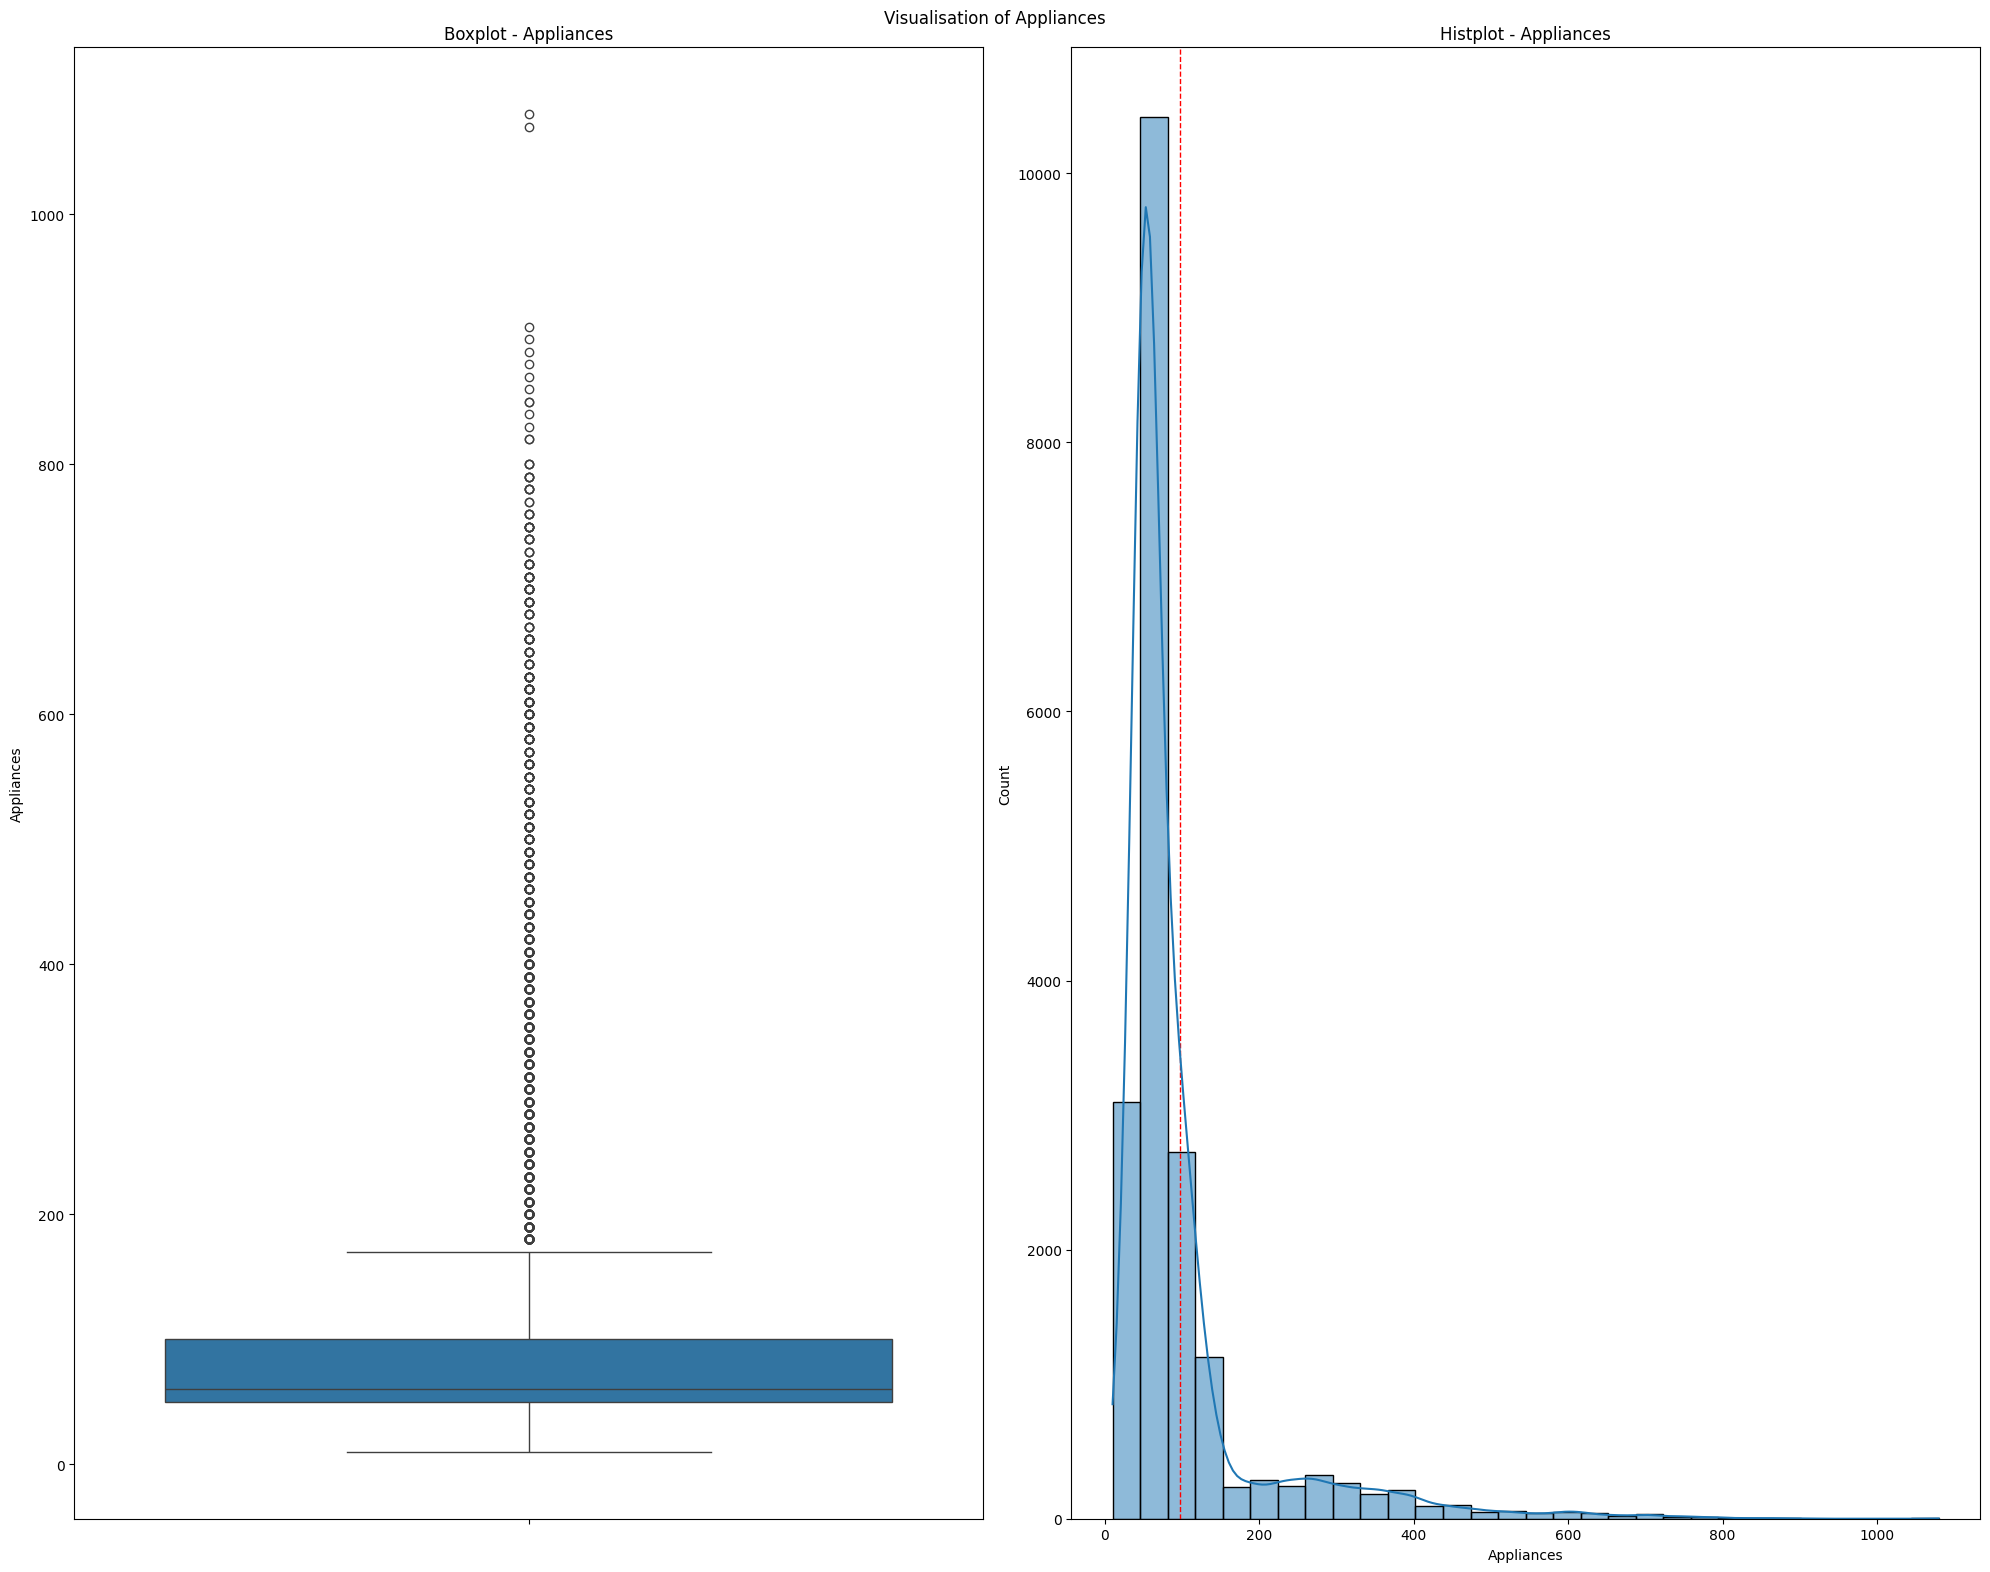

In [9]:
target_feature = "Appliances"

plt.figure(figsize=(20, 16))

plt.subplot(1, 2, 1)
plt.title(f"Boxplot - {target_feature}")
sns.boxplot(df_og[target_feature])

plt.subplot(1, 2, 2)
plt.title(f"Histplot - {target_feature}")
plt.axvline(df_og[target_feature].mean(), color="r", linestyle="dashed", linewidth=1)
sns.histplot(df_og[target_feature].dropna(), kde=True, bins=30)

plt.suptitle(f"Visualisation of {target_feature}")
plt.tight_layout()
plt.show()

Our data has a lot of outliers but it can be useful because of it being time series data, and out output isnt normally distributed

## Feature selection

In [10]:
columns_to_drop = ["rv1", "rv2", "date"]

df = df_og.drop(columns=columns_to_drop, axis = 1)

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9


In [11]:
X = df.drop(target_feature, axis=1)
y = df[target_feature]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (19735, 25)
y Shape: (19735,)


## Pipeline Preparation

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            make_column_selector(dtype_include=["number", "float64", "int64"]),
        ),
        (
            "cat",
            LabelEncoder(),
            make_column_selector(dtype_include="object"),
        ),
    ]
)

## Data Splitting

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (15788, 25)
y_train shape: (15788,)
X_test shape: (3947, 25)
y_test shape: (3947,)


## Base model

In [14]:
lr_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessor),
        ("Model", LinearRegression()),
    ]
)

lr_pipeline.fit(X_train, y_train)
lr_pipeline

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000171F8A55370>),
                                                 ('cat', LabelEncoder(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000171F851E720>)])),
                ('Model', LinearRegression())])

In [15]:
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse_lr}")
print(f"R2: {r2_lr}")

RMSE: 91.17165866389198
R2: 0.16936187895229782


## SVR

In [16]:
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score

svr_pipeline = Pipeline(
    steps=[("Preprocessing", preprocessor), ("Model", SVR())]
)

svr_pipeline.fit(X_train, y_train)

y_pred_svr = svr_pipeline.predict(X_test)

rmse_svr = root_mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR (RBF)")
print(f"RMSE: {rmse_svr}")
print(f"R2: {r2_svr}")

SVR (RBF)
RMSE: 98.30237144382718
R2: 0.034349128967781084


## SVR Linear

In [17]:
svr_linear_pipeline = Pipeline(
    steps=[("Preprocessing", preprocessor), ("Model", LinearSVR())]
)

svr_linear_pipeline.fit(X_train, y_train)

y_pred_svr_linear = svr_linear_pipeline.predict(X_test)

rmse_svr_linear = root_mean_squared_error(y_test, y_pred_svr_linear)
r2_svr_linear = r2_score(y_test, y_pred_svr_linear)

print("SVR (Linear)")
print(f"RMSE: {rmse_svr_linear}")
print(f"R2: {r2_svr_linear}")

SVR (Linear)
RMSE: 97.89930776422791
R2: 0.04225170225524477


## Random Forest Regressor

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(
    steps=[
        ("Preprocessing", preprocessor),
        ("Model", RandomForestRegressor(n_estimators=100, random_state=42)),
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"RMSE: {rmse_rf}")
print(f"R2: {r2_rf}")

Random Forest
RMSE: 67.96757017423018
R2: 0.5383682878504161


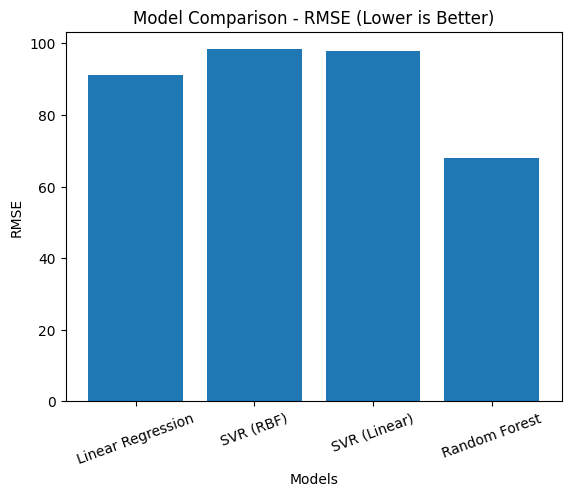

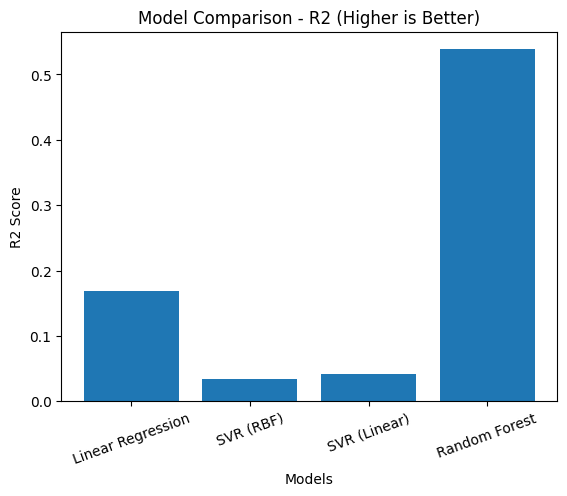

In [19]:
models = ["Linear Regression", "SVR (RBF)", "SVR (Linear)", "Random Forest"]

rmse_scores = [rmse_lr, rmse_svr, rmse_svr_linear, rmse_rf]
r2_scores = [r2_lr, r2_svr, r2_svr_linear, r2_rf]

# RMSE Plot (Lower is Better)
plt.figure()
plt.bar(models, rmse_scores)
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE (Lower is Better)")
plt.xticks(rotation=20)
plt.show()

# R2 Plot (Higher is Better)
plt.figure()
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison - R2 (Higher is Better)")
plt.xticks(rotation=20)
plt.show()

# Conclusion

- Random forest performed the best with
  - R2: 54%
  - RMSE: 68